In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#create a customer dataset
customers = {

    "customer_id":[1,2,3,4,5,6,7,8,9,10],

    "age":[25,34,29,42,31,55,48,23,39,61],

    "monthly_income":[
        50000,
        120000,
        65000,
        200000,
        85000,
        300000,
        150000,
        40000,
        95000,
        450000
    ],

    "loan_amount":[
        100000,
        500000,
        150000,
        800000,
        250000,
        1000000,
        400000,
        80000,
        300000,
        1200000
    ],

    "days_in_arrears":[
        0,
        5,
        0,
        30,
        15,
        60,
        0,
        0,
        10,
        90
    ]
}

df = pd.DataFrame(customers)

df

,customer_id,age,monthly_income,loan_amount,days_in_arrears
0,1,25,50000,100000,0
1,2,34,120000,500000,5
2,3,29,65000,150000,0
3,4,42,200000,800000,30
4,5,31,85000,250000,15
5,6,55,300000,1000000,60
6,7,48,150000,400000,0
7,8,23,40000,80000,0
8,9,39,95000,300000,10
9,10,61,450000,1200000,90


In [4]:
#now let's understand the data by looking at the summary statistics
df.describe()

,customer_id,age,monthly_income,loan_amount,days_in_arrears
count,10.00000,10.000000,10.000000,1.000000e+01,10.00000
mean,5.50000,38.700000,155500.000000,4.780000e+05,21.00000
std,3.02765,12.780628,130030.979215,3.939205e+05,30.80404
min,1.00000,23.000000,40000.000000,8.000000e+04,0.00000
25%,3.25000,29.500000,70000.000000,1.750000e+05,0.00000
50%,5.50000,36.500000,107500.000000,3.500000e+05,7.50000
75%,7.75000,46.500000,187500.000000,7.250000e+05,26.25000
max,10.00000,61.000000,450000.000000,1.200000e+06,90.00000


Let's Dive Down on Customer Demographics

In [5]:
#Average customer age
average_age = df["age"].mean()
average_age

np.float64(38.7)

In [6]:
#youngest customer age
youngest_customer = df["age"].min()
youngest_customer

np.int64(23)

In [7]:
#oldest customer age
oldest_customer = df["age"].max()
oldest_customer

np.int64(61)

In [8]:
#what age group dominates the dataset?
age_groups = pd.cut(df["age"], bins=[0, 18, 35, 50, 100], labels=["0-18", "19-35", "36-50", "51+"])
age_group_counts = age_groups.value_counts()
age_group_counts

age
19-35    5
36-50    3
51+      2
0-18     0
Name: count, dtype: int64

<Axes: >

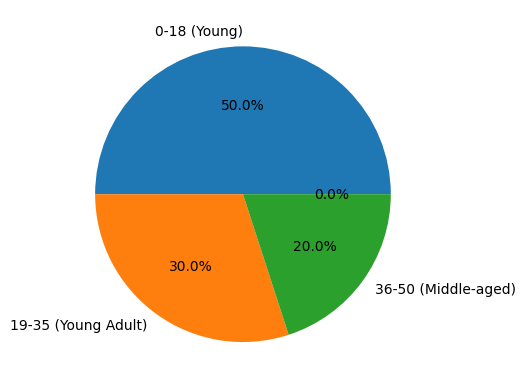

In [9]:
#are our customers mostly young, middle-aged, or older?
#we can rename these labels to make them more descriptive
age_group_counts.index = ["0-18 (Young)", "19-35 (Young Adult)", "36-50 (Middle-aged)", "51+ (Older)"]
age_group_counts.plot(kind="pie", autopct="%1.1f%%")

Let's Dive down on Income Analytics


In [10]:
#average monthly income
average_income = df["monthly_income"].mean()
average_income

np.float64(155500.0)

In [11]:
#median monthly income
median_income = df["monthly_income"].median()
median_income

np.float64(107500.0)

In [12]:
#highest monthly income
highest_income = df["monthly_income"].max()
highest_income

np.int64(450000)

In [13]:

#lowest monthly income
lowest_income = df["monthly_income"].min()  
lowest_income

np.int64(40000)

In [14]:
#how much income variability exsists in our dataset?
income_variability = df["monthly_income"].describe()
income_variability

count        10.000000
mean     155500.000000
std      130030.979215
min       40000.000000
25%       70000.000000
50%      107500.000000
75%      187500.000000
max      450000.000000
Name: monthly_income, dtype: float64

Let's dive down on Loan Analytics


In [15]:
#average loan amount
average_loan_amount = df["loan_amount"].mean()
average_loan_amount

np.float64(478000.0)

In [16]:
#total portfolio exposure
total_portfolio_exposure = df["loan_amount"].sum()
total_portfolio_exposure

np.int64(4780000)

In [17]:
#let's check affordability by calculating the loan-to-income ratio
df["loan_to_income_ratio"] = df["loan_amount"] / df["monthly_income"]
df["loan_to_income_ratio"]
#let's now label customers as "affordable" or "unaffordable" based on a loan-to-income ratio threshold of 4 as unaffordable, between 3 and 4 as borderline, and below 3 as affordable
df["affordability"] = np.where(df["loan_to_income_ratio"] < 3, "Affordable", np.where(df["loan_to_income_ratio"] <= 4, "Borderline", "Unaffordable"))
df[["customer_id", "loan_to_income_ratio", "affordability"]]
df["risk_category"] = np.where(df["affordability"] == "Affordable", "Low Risk", np.where(df["affordability"] == "Borderline", "Medium Risk", "High Risk"))
df[["customer_id", "loan_to_income_ratio", "affordability", "risk_category"]]

,customer_id,loan_to_income_ratio,affordability,risk_category
0,1,2.000000,Affordable,Low Risk
1,2,4.166667,Unaffordable,High Risk
2,3,2.307692,Affordable,Low Risk
3,4,4.000000,Borderline,Medium Risk
4,5,2.941176,Affordable,Low Risk
5,6,3.333333,Borderline,Medium Risk
6,7,2.666667,Affordable,Low Risk
7,8,2.000000,Affordable,Low Risk
8,9,3.157895,Borderline,Medium Risk
9,10,2.666667,Affordable,Low Risk


In [18]:
#let's create affprdability portfolio analysis
df["affordability_band"] = pd.cut(

    df["loan_to_income_ratio"],

    bins=[0,3,5,10,100],

    labels=[
        "Healthy",
        "Moderate",
        "Risky",
        "Severely Overleveraged"
    ]
)

df["affordability_band"].value_counts()

affordability_band
Healthy                   6
Moderate                  4
Risky                     0
Severely Overleveraged    0
Name: count, dtype: int64

In [19]:
#let's now define next decisions based on the number of days in arrears and the risk category
df["next_decision"] = np.where((df["days_in_arrears"] == 0) & (df["risk_category"] == "Low Risk"), "Approve", np.where((df["days_in_arrears"] <= 15) & (df["risk_category"] == "Medium Risk"), "Review", np.where(df["days_in_arrears"] <= 30, "Review Limit to Ksh 0", np.where(df["days_in_arrears"] <= 60, "List Customer to CRB", "List Customer to CRB"))))
df[["customer_id", "days_in_arrears", "risk_category", "next_decision"]]    

,customer_id,days_in_arrears,risk_category,next_decision
0,1,0,Low Risk,Approve
1,2,5,High Risk,Review Limit to Ksh 0
2,3,0,Low Risk,Approve
3,4,30,Medium Risk,Review Limit to Ksh 0
4,5,15,Low Risk,Review Limit to Ksh 0
5,6,60,Medium Risk,List Customer to CRB
6,7,0,Low Risk,Approve
7,8,0,Low Risk,Approve
8,9,10,Medium Risk,Review
9,10,90,Low Risk,List Customer to CRB
